In [1]:
import numpy as np
from scipy.optimize import minimize

# Rosenbrock function
def rosen(x):
    x = np.asarray(x)
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

# Starting point
x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])

# Run Powell’s method
res = minimize(rosen, x0, method='Powell', options={'disp': True})

# Show results
print("Minimum Value        :", res.fun)
print("Optimum at           :", res.x)
print("Function evaluations :", res.nfev)
print("Number of Iterations :", res.nit)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 18
         Function evaluations: 988
Minimum Value        : 1.6967633615782998e-22
Optimum at           : [1. 1. 1. 1. 1.]
Function evaluations : 988
Number of Iterations : 18


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 25
         Function evaluations: 670


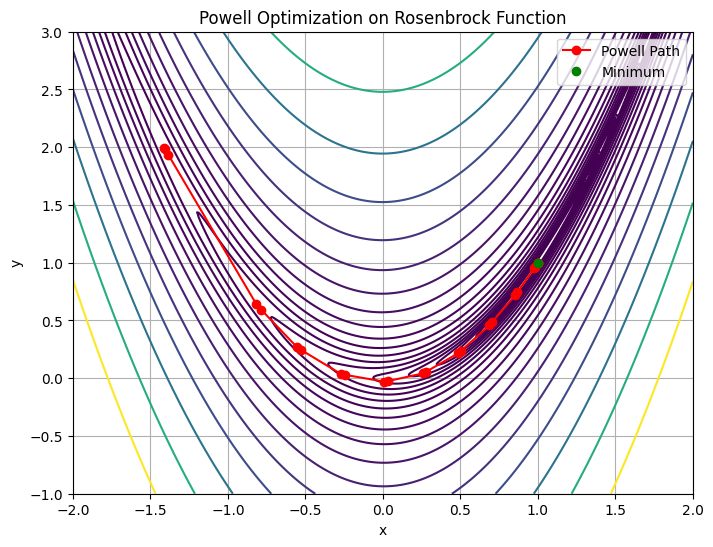

In [2]:
import matplotlib.pyplot as plt

# 2D Rosenbrock function for plotting
def rosen2(xy):
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

# Track optimization path
path = []
def record_path(xk):
    path.append(np.copy(xk))

# Redo optimization with 2D input
x0 = np.array([-1.5, 2.0])
res = minimize(rosen, x0, method='Powell', callback=record_path, options={'disp': True})

# Grid for contour
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosen2([X, Y])

# Convert path to array
path2d = np.array([p[:2] for p in path])

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='viridis')
plt.plot(*path2d.T, 'ro-', label='Powell Path')
plt.plot(res.x[0], res.x[1], 'go', label='Minimum')
plt.title("Powell Optimization on Rosenbrock Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()